# Feature Selection
Create two versions of the training dataset:
1. **Model A**: 15-20 features (broader set)
2. **Model B**: 7 features (trimmed, low redundancy)

We'll compare model performance to see if fewer features actually helps.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
df = pd.read_csv('../data/processed/tournament_matchups.csv')
print(f'Full dataset: {df.shape}')

Full dataset: (477, 91)


## 1. Review Feature Correlations with Target

In [2]:
# Get all differential columns
diff_cols = [c for c in df.columns if c.startswith('diff_')]
diff_cols.append('seed_diff')

# Correlation with home_win
correlations = df[diff_cols + ['home_win']].corr()['home_win'].drop('home_win')
correlations = correlations.sort_values(key=abs, ascending=False)

print('Feature correlations with home_win (sorted by |r|):')
print('='*55)
for i, (feat, corr) in enumerate(correlations.items(), 1):
    sign = '+' if corr > 0 else '-'
    bar = '█' * int(abs(corr) * 40)
    print(f'{i:2d}. {feat:20s} {sign}{abs(corr):.4f}  {bar}')

Feature correlations with home_win (sorted by |r|):
 1. diff_srs             +0.4212  ████████████████
 2. diff_pts_for         +0.4121  ████████████████
 3. diff_trb             +0.3497  █████████████
 4. diff_sos             +0.3192  ████████████
 5. seed_diff            +0.3016  ████████████
 6. diff_pts_against     +0.2862  ███████████
 7. diff_ast             +0.2657  ██████████
 8. diff_win_pct         +0.2309  █████████
 9. diff_three_made      +0.2257  █████████
10. diff_ortg            +0.1973  ███████
11. diff_blk             +0.1939  ███████
12. diff_stl             +0.1690  ██████
13. diff_tov_pct         -0.1606  ██████
14. diff_pace            -0.1269  █████
15. diff_ts_pct          +0.1177  ████
16. diff_tov             +0.1132  ████
17. diff_ft_pct          +0.1117  ████
18. diff_fg_pct          +0.1096  ████
19. diff_efg_pct         +0.1094  ████
20. diff_three_pct       +0.0991  ███
21. diff_blk_pct         +0.0774  ███
22. diff_ftr             -0.0653  ██
23. diff_tr

## 2. Check Feature-to-Feature Correlations (Multicollinearity)

In [3]:
# Correlation matrix for differential features
corr_matrix = df[diff_cols].corr()

# Find highly correlated pairs (|r| > 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                r
            ))

print('Highly correlated feature pairs (|r| > 0.7):')
print('='*60)
for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {f1:20s} <-> {f2:20s}  r={r:.3f}')

Highly correlated feature pairs (|r| > 0.7):
  diff_efg_pct         <-> diff_ts_pct           r=0.975
  diff_stl_pct         <-> diff_stl              r=0.942
  diff_efg_pct         <-> diff_fg_pct           r=0.930
  diff_ftr             <-> diff_ft_fga           r=0.926
  diff_blk_pct         <-> diff_blk              r=0.912
  diff_ts_pct          <-> diff_fg_pct           r=0.909
  diff_srs             <-> seed_diff             r=0.846
  diff_three_par       <-> diff_three_made       r=0.830
  diff_ortg            <-> diff_ts_pct           r=0.815
  diff_ortg            <-> diff_efg_pct          r=0.811
  diff_tov_pct         <-> diff_tov              r=0.786
  diff_ast_pct         <-> diff_ast              r=0.769
  diff_ortg            <-> diff_fg_pct           r=0.764
  diff_pts_for         <-> diff_pts_against      r=0.756
  diff_efg_pct         <-> diff_three_pct        r=0.715
  diff_srs             <-> diff_sos              r=0.712
  diff_pts_for         <-> diff_ast        

## 3. Select Features for Model A (15-20 features)
Keep features with decent correlation to target, avoiding highly redundant pairs.

In [4]:
# Model A: Broader feature set (15-20 features)
# Selection criteria:
# - Include top correlated features
# - When two features are highly correlated, keep the one with higher target correlation
# - Include some context features even if lower correlation

model_a_features = [
    # Tier 1: Strong predictors
    'diff_srs',           # Best overall predictor
    'diff_win_pct',       # Win percentage differential
    'diff_sos',           # Strength of schedule
    'diff_ortg',          # Offensive rating
    'diff_efg_pct',       # Effective FG%
    'diff_tov_pct',       # Turnover rate (negative = good)
    'diff_orb_pct',       # Offensive rebound %
    'seed_diff',          # Seed differential
    
    # Tier 2: Moderate predictors
    'diff_ftr',           # Free throw rate
    'diff_ts_pct',        # True shooting %
    'diff_ft_pct',        # Free throw %
    'diff_pace',          # Tempo
    'diff_pts_for',       # Points scored
    'diff_pts_against',   # Points allowed
    
    # Tier 3: Supporting features
    'diff_ast_pct',       # Assist rate
    'diff_stl_pct',       # Steal rate
    'diff_blk_pct',       # Block rate
    'diff_trb_pct',       # Total rebound %
    'diff_three_par',     # 3-point attempt rate
    'diff_three_pct',     # 3-point %
]

print(f'Model A: {len(model_a_features)} features')
for i, f in enumerate(model_a_features, 1):
    corr = correlations.get(f, 0)
    print(f'  {i:2d}. {f:20s}  r={corr:+.4f}')

Model A: 20 features
   1. diff_srs              r=+0.4212
   2. diff_win_pct          r=+0.2309
   3. diff_sos              r=+0.3192
   4. diff_ortg             r=+0.1973
   5. diff_efg_pct          r=+0.1094
   6. diff_tov_pct          r=-0.1606
   7. diff_orb_pct          r=+0.0445
   8. seed_diff             r=+0.3016
   9. diff_ftr              r=-0.0653
  10. diff_ts_pct           r=+0.1177
  11. diff_ft_pct           r=+0.1117
  12. diff_pace             r=-0.1269
  13. diff_pts_for          r=+0.4121
  14. diff_pts_against      r=+0.2862
  15. diff_ast_pct          r=+0.0150
  16. diff_stl_pct          r=+0.0397
  17. diff_blk_pct          r=+0.0774
  18. diff_trb_pct          r=+0.0541
  19. diff_three_par        r=+0.0107
  20. diff_three_pct        r=+0.0991


In [5]:
# Model B: Trimmed feature set (7 features)
# Strict selection: high correlation, low redundancy

model_b_features = [
    'diff_srs',           # Best predictor
    'diff_win_pct',       # Simple but strong
    'diff_efg_pct',       # Shooting efficiency
    'diff_tov_pct',       # Ball security
    'diff_orb_pct',       # Second chances
    'diff_ftr',           # Getting to the line
    'seed_diff',          # Committee knowledge
]

print(f'Model B: {len(model_b_features)} features')
for i, f in enumerate(model_b_features, 1):
    corr = correlations.get(f, 0)
    print(f'  {i:2d}. {f:20s}  r={corr:+.4f}')

Model B: 7 features
   1. diff_srs              r=+0.4212
   2. diff_win_pct          r=+0.2309
   3. diff_efg_pct          r=+0.1094
   4. diff_tov_pct          r=-0.1606
   5. diff_orb_pct          r=+0.0445
   6. diff_ftr              r=-0.0653
   7. seed_diff             r=+0.3016


## 4. Visualize Feature Correlations for Both Sets

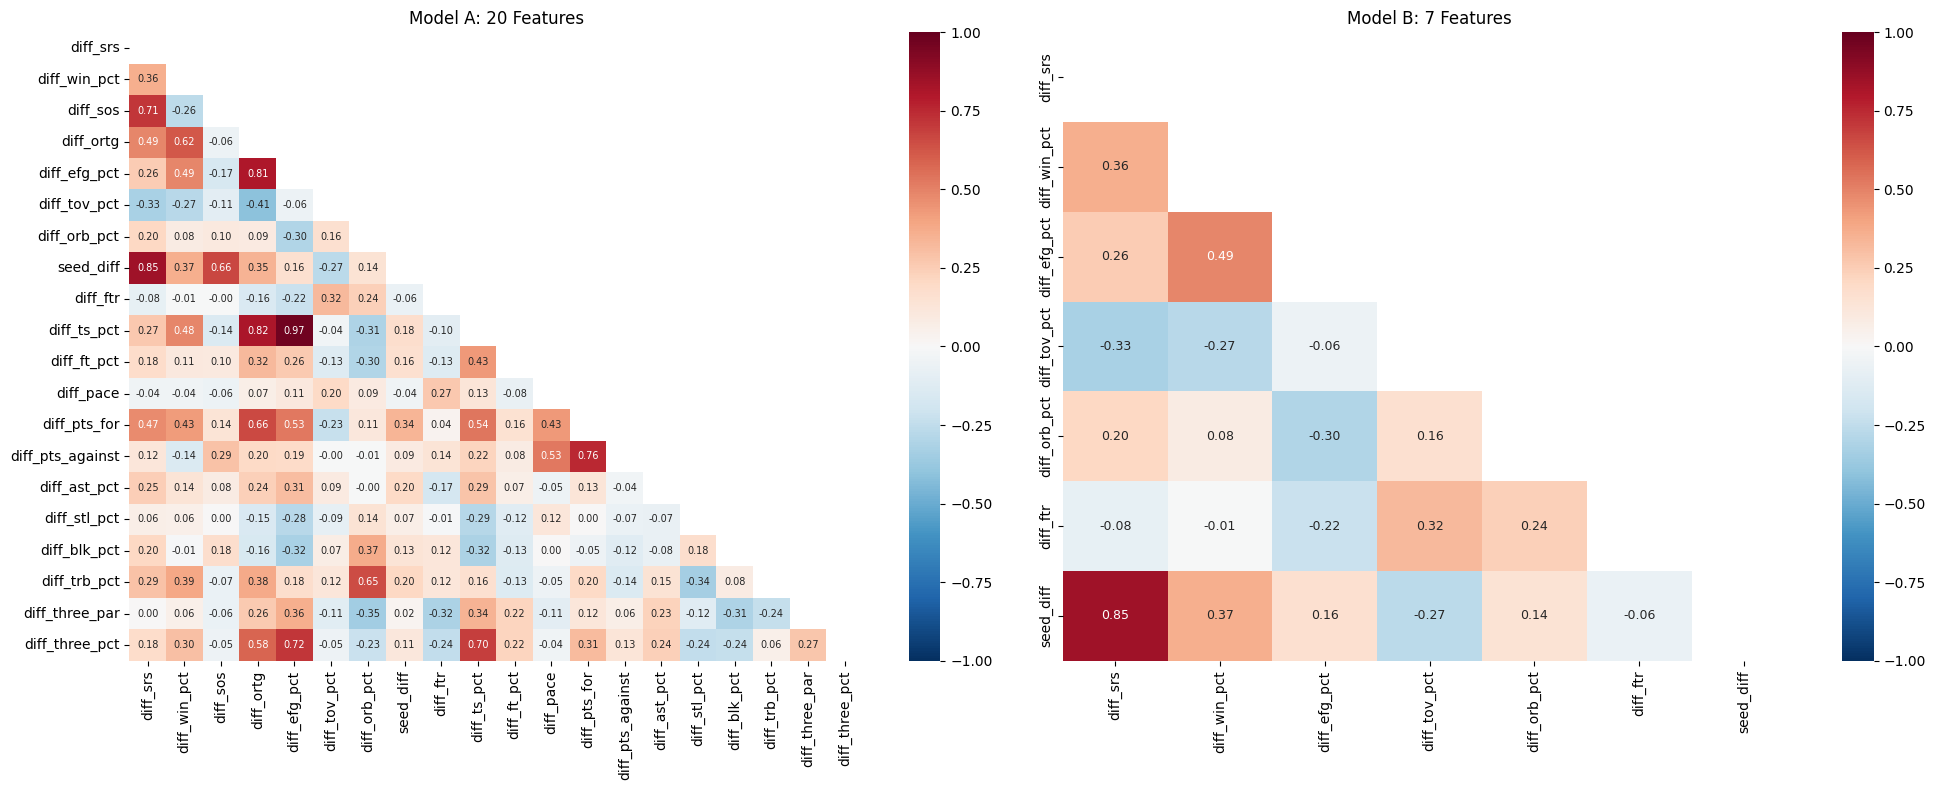

In [6]:
# Correlation matrix for Model A features
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Model A
corr_a = df[model_a_features].corr()
mask_a = np.triu(np.ones_like(corr_a, dtype=bool))
sns.heatmap(corr_a, mask=mask_a, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={'size': 7})
axes[0].set_title(f'Model A: {len(model_a_features)} Features', fontsize=12)

# Model B
corr_b = df[model_b_features].corr()
mask_b = np.triu(np.ones_like(corr_b, dtype=bool))
sns.heatmap(corr_b, mask=mask_b, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[1], annot_kws={'size': 9})
axes[1].set_title(f'Model B: {len(model_b_features)} Features', fontsize=12)

plt.tight_layout()
plt.savefig('../results/visualizations/model_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Create and Save Trimmed Datasets

In [7]:
# Metadata columns to keep
meta_cols = ['season', 'round', 'home_team', 'away_team', 'home_seed', 'away_seed', 
             'home_score', 'away_score', 'home_win']

# Create Model A dataset
df_model_a = df[meta_cols + model_a_features].copy()
print(f'Model A dataset: {df_model_a.shape}')
print(f'  Missing values: {df_model_a[model_a_features].isna().sum().sum()}')

# Create Model B dataset
df_model_b = df[meta_cols + model_b_features].copy()
print(f'\nModel B dataset: {df_model_b.shape}')
print(f'  Missing values: {df_model_b[model_b_features].isna().sum().sum()}')

Model A dataset: (477, 29)
  Missing values: 0

Model B dataset: (477, 16)
  Missing values: 0


In [8]:
# Check for any missing values
print('Missing values per feature (Model A):')
missing = df_model_a[model_a_features].isna().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print('  None!')

Missing values per feature (Model A):
  None!


In [9]:
# Save datasets
output_dir = Path('../data/processed')

df_model_a.to_csv(output_dir / 'matchups_model_a.csv', index=False)
df_model_b.to_csv(output_dir / 'matchups_model_b.csv', index=False)

print(f'Saved: matchups_model_a.csv ({len(model_a_features)} features)')
print(f'Saved: matchups_model_b.csv ({len(model_b_features)} features)')

Saved: matchups_model_a.csv (20 features)
Saved: matchups_model_b.csv (7 features)


In [10]:
# Preview Model A
print('Model A Preview:')
df_model_a.head(10)

Model A Preview:


,season,round,home_team,away_team,home_seed,away_seed,home_score,away_score,home_win,diff_srs,diff_win_pct,diff_sos,diff_ortg,diff_efg_pct,diff_tov_pct,diff_orb_pct,seed_diff,diff_ftr,diff_ts_pct,diff_ft_pct,diff_pace,diff_pts_for,diff_pts_against,diff_ast_pct,diff_stl_pct,diff_blk_pct,diff_trb_pct,diff_three_par,diff_three_pct
0,2014,F4,Texas Southern Tigers,Cal Poly Mustangs,16,16,69,81,0,-7.07,0.147,-11.76,6.3,0.055,4.2,2.0,0,0.165,0.064,0.030,7.4,443,349,3.2,-3.0,0.5,3.4,-0.029,0.027
1,2014,F4,Tennessee Volunteers,Iowa Hawkeyes,11,11,78,65,1,-1.24,0.043,0.41,-0.8,-0.008,0.4,2.1,0,-0.037,-0.013,-0.016,-7.0,-17,-38,-7.0,-1.8,-1.5,1.5,0.033,-0.025
2,2014,R64,Ohio State Buckeyes,Dayton Flyers,6,11,59,60,0,7.29,0.011,2.78,-3.5,-0.021,-0.6,-4.4,5,0.017,-0.015,0.008,-0.4,-239,-386,-2.0,2.7,4.9,-2.5,0.010,-0.053
3,2014,R64,Colorado Buffaloes,Pittsburgh Panthers,8,9,48,77,0,-6.66,-0.065,1.26,-9.3,-0.024,3.1,-3.3,1,0.040,-0.016,0.006,4.5,-129,158,-14.1,-2.4,0.4,-0.2,0.035,-0.033
4,2014,R64,Cincinnati Bearcats,Harvard Crimson,5,12,57,61,0,4.47,-0.050,5.75,-4.0,-0.042,-0.6,6.3,7,-0.093,-0.045,-0.016,-1.0,-18,34,-4.3,0.8,2.6,1.1,0.026,-0.050
5,2014,R64,Syracuse Orange,Western Michigan Broncos,3,14,77,53,1,14.32,0.127,8.70,5.1,-0.038,-6.1,6.5,11,-0.126,-0.046,-0.016,-6.0,-62,-223,0.8,4.4,7.6,1.5,-0.082,0.002
6,2014,R64,Oregon Ducks,BYU Cougars,7,10,87,68,1,4.12,0.049,2.33,3.1,0.032,1.2,-2.5,3,-0.045,0.038,0.080,-3.6,-148,-185,-0.8,1.3,1.4,-2.6,0.109,0.034
7,2014,R64,UConn Huskies,Saint Joseph's Hawks,7,10,89,81,1,8.18,0.094,3.55,0.8,-0.024,-0.7,1.4,3,-0.053,-0.001,0.132,-0.5,440,231,-6.4,4.0,3.3,-1.8,-0.026,0.008
8,2014,R64,Michigan Wolverines,Wofford Terriers,2,15,57,40,1,22.84,0.151,15.60,11.9,0.055,-1.7,-3.1,13,0.021,0.063,0.099,-0.6,531,354,3.2,-1.6,1.7,-0.9,0.099,0.042
9,2014,R64,Oklahoma Sooners,North Dakota State Bison,5,12,75,80,0,8.60,-0.091,8.99,-4.7,-0.038,0.1,0.7,7,-0.015,-0.033,-0.002,7.8,212,344,10.1,-0.3,-4.7,-2.3,0.095,0.015


In [11]:
# Summary stats for Model A features
df_model_a[model_a_features].describe()

,diff_srs,diff_win_pct,diff_sos,diff_ortg,diff_efg_pct,diff_tov_pct,diff_orb_pct,seed_diff,diff_ftr,diff_ts_pct,diff_ft_pct,diff_pace,diff_pts_for,diff_pts_against,diff_ast_pct,diff_stl_pct,diff_blk_pct,diff_trb_pct,diff_three_par,diff_three_pct
count,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000,477.000000
mean,7.813501,0.067652,4.242096,2.728512,0.008482,-0.494759,1.321803,6.096436,0.000172,0.008004,0.004952,0.033124,128.997904,12.310273,1.110482,0.105660,0.821803,0.958071,-0.003449,0.006474
std,8.231832,0.127713,6.346030,6.464254,0.039736,1.967646,5.453361,4.280983,0.060627,0.035929,0.048857,3.793104,323.322474,267.036735,7.565299,2.507189,3.843354,3.255990,0.066830,0.035575
min,-8.260000,-0.278000,-11.760000,-13.400000,-0.100000,-6.500000,-14.700000,0.000000,-0.169000,-0.087000,-0.115000,-11.200000,-782.000000,-731.000000,-20.000000,-8.100000,-11.200000,-9.500000,-0.226000,-0.101000
25%,1.940000,-0.021000,-0.600000,-1.600000,-0.019000,-1.800000,-2.300000,3.000000,-0.041000,-0.018000,-0.031000,-2.400000,-90.000000,-173.000000,-4.100000,-1.500000,-1.900000,-1.200000,-0.051000,-0.019000
50%,6.400000,0.062000,2.760000,2.200000,0.008000,-0.500000,1.600000,5.000000,0.001000,0.008000,0.008000,0.200000,127.000000,13.000000,1.400000,0.100000,0.800000,0.900000,-0.003000,0.007000
75%,11.980000,0.156000,9.220000,6.600000,0.038000,0.900000,5.000000,9.000000,0.040000,0.032000,0.038000,2.700000,352.000000,189.000000,6.100000,1.700000,3.500000,3.100000,0.044000,0.031000
max,36.970000,0.560000,20.280000,21.000000,0.126000,5.700000,17.000000,15.000000,0.194000,0.110000,0.163000,9.800000,1241.000000,1150.000000,23.700000,7.500000,12.300000,11.200000,0.183000,0.105000
